# Otimização Unidimensional — Bisseção, Divisão Áurea e Newton 1D

Tradução em Python dos scripts MATLAB da pasta `Opt_1D` (`MAIN_1D.m`, `Bissecao.m`,
`DivisaoAurea.m`, `Newton1D.m`, `f.m`, `dfdx.m`, `df2dx2.m`, `graf.m`).

Minimização, sem restrições, da função quadrática de teste $f(x) = (x-2)^2$ (mínimo exato
em $x^*=2$) por três métodos clássicos de busca unidimensional:
- **Bisseção** — usa apenas o sinal da derivada $f'(x)$ para bisseccionar o intervalo;
- **Divisão Áurea** — usa apenas avaliações de $f(x)$ (método de busca direta);
- **Newton 1D** — usa $f'(x)$ e $f''(x)$, convergência quadrática a partir de um chute
  inicial $x_0$.

Cada método retorna o histórico de iterações $x_k$, usado para o gráfico de convergência.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Função objetivo e derivadas (`f.m`, `dfdx.m`, `df2dx2.m`)

In [2]:
def f(x):
    """Função objetivo 1D."""
    return (x - 2) ** 2


def dfdx(x):
    """Gradiente da função objetivo 1D."""
    return 2 * x - 4


def df2dx2(x):
    """Segunda derivada (Hessiana) da função objetivo 1D."""
    return 2

## Métodos de busca unidimensional (`Bissecao.m`, `DivisaoAurea.m`, `Newton1D.m`)

Cada função retorna o ponto ótimo $X$ e o histórico de iterações (para plot de
convergência), fielmente ao critério de parada e ao limite de 100 iterações do original.

In [3]:
def bissecao(I):
    """Busca pelo método de Bisseção. Precisa de dfdx."""
    eps = 1e-5
    ak, bk = I
    Lk = bk - ak

    x = [(ak + bk) / 2]
    k = 0   # índice 0-based (k=1 no MATLAB)

    while Lk > 2 * eps:
        mk = (ak + bk) / 2
        x.append(mk)

        flinha = dfdx(mk)
        if flinha == 0:
            break

        if flinha > 0:
            bk = mk
        else:
            ak = mk
        Lk = bk - ak

        k += 1
        if k == 99:
            break

    return x[-1], x


def divisao_aurea(I):
    """Busca pelo método da Divisão Áurea. Precisa de f."""
    eps = 1e-5
    ak, bk = I
    Lk = bk - ak

    x = [(ak + bk) / 2]
    k = 0

    while Lk > 2 * eps:
        vk = ak + 0.382 * Lk
        wk = ak + 0.618 * Lk

        if f(vk) < f(wk):
            bk = wk
        else:
            ak = vk
        Lk = bk - ak

        x.append((ak + bk) / 2)
        k += 1
        if k == 99:
            break

    return x[-1], x


def newton1d(I, x0):
    """Busca pelo método de Newton 1D. Precisa de f, dfdx e df2dx2."""
    eps = 1e-5
    x = [x0]
    k = 0
    converged = False

    while not converged:
        x.append(x[k] - dfdx(x[k]) / df2dx2(x[k]))

        if (x[k + 1] - x[k]) / x[k + 1] <= eps:
            converged = True

        k += 1
        if k == 99:
            break

    return x[-1], x


def graf(I, X):
    """Curva da função no intervalo, com o ponto ótimo marcado."""
    x = np.arange(I[0], I[1], 0.01)
    y = f(x)
    plt.figure(figsize=(6, 4))
    plt.plot(x, y)
    plt.plot(X, f(X), '*')
    plt.title('Curva da função')
    plt.grid(True)
    plt.show()

## Execução (`MAIN_1D.m`)

Intervalo inicial $I=[1,4]$ e chute inicial $x_0=1$ (usado apenas por Newton). O script
original executa um único método por vez (comentando os demais); aqui os três são
executados e comparados.

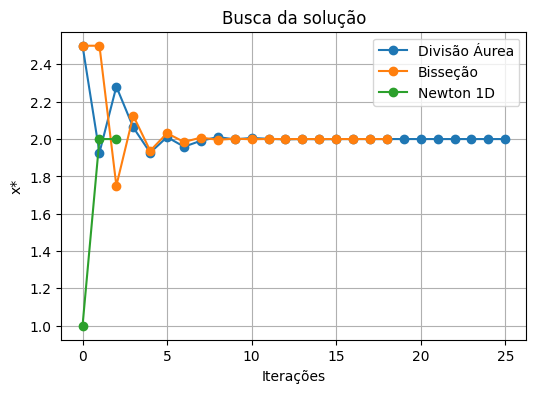

--- Divisão Áurea ---
Ponto ótimo: x* = 2.000004
Valor mínimo de f(x): fmin = 0.000000

--- Bisseção ---
Ponto ótimo: x* = 1.999996
Valor mínimo de f(x): fmin = 0.000000

--- Newton 1D ---
Ponto ótimo: x* = 2.000000
Valor mínimo de f(x): fmin = 0.000000



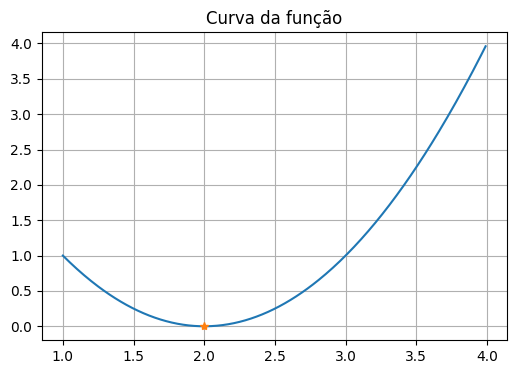

In [4]:
I = [1, 4]
x0 = 1

resultados = {}
resultados['Divisão Áurea'] = divisao_aurea(list(I))
resultados['Bisseção'] = bissecao(list(I))
resultados['Newton 1D'] = newton1d(list(I), x0)

plt.figure(figsize=(6, 4))
for nome, (X, historico) in resultados.items():
    plt.plot(range(len(historico)), historico, marker='o', label=nome)
plt.title('Busca da solução')
plt.xlabel('Iterações')
plt.ylabel('x*')
plt.legend()
plt.grid(True)
plt.show()

for nome, (X, historico) in resultados.items():
    print(f'--- {nome} ---')
    print(f'Ponto ótimo: x* = {X:.6f}')
    print(f'Valor mínimo de f(x): fmin = {f(X):.6f}\n')

# Gráfico final da função, com o ponto ótimo de Newton 1D marcado
X_newton, _ = resultados['Newton 1D']
graf(I, X_newton)